In [8]:
import pandas as pd

df = pd.read_csv(r"D:\Guvidata\Amazon_Music_Clustering\single_genre_artists.csv")

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  str    
 1   name_song           95837 non-null  str    
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  str    
 6   release_date        95837 non-null  str    
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  valence        

In [10]:
df = df.drop(
    columns=[
        "id_songs",
        "name_song",
        "id_artists",
        "name_artists",
        "genres",
        "release_date",
        "followers",
        "popularity_songs",
        "popularity_artists",
        "key",
        "mode",
        "time_signature",
        "explicit"
    ]
)

In [11]:
features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms"
]

X = df[features]

## Feature Scaling

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Verify scaling

In [13]:
import pandas as pd

scaled_df = pd.DataFrame(X_scaled, columns=features)

scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,95837.0,2.704655e-16,1.000005,-3.775894,-0.636036,0.116758,0.728001,2.600334
energy,95837.0,7.592013e-17,1.000005,-2.289708,-0.745160,0.003880,0.786775,1.942075
loudness,95837.0,7.592013e-17,1.000005,-8.426626,-0.540169,0.160223,0.729844,3.271131
speechiness,95837.0,-7.592013e-17,1.000005,-0.613010,-0.489197,-0.445263,-0.239029,2.901684
acousticness,95837.0,-9.490016e-17,1.000005,-1.389130,-0.986605,-0.018124,0.907986,1.625267
instrumentalness,95837.0,9.490016e-18,1.000005,-0.353405,-0.353405,-0.353388,-0.347812,3.948808
liveness,95837.0,-2.847005e-17,1.000005,-1.210346,-0.672214,-0.408529,0.414813,4.154831
valence,95837.0,4.448445e-17,1.000005,-2.314486,-0.791058,0.059322,0.829096,1.715748
tempo,95837.0,-1.992903e-16,1.000005,-3.893307,-0.752259,-0.031297,0.610632,4.053168
duration_ms,95837.0,-6.643011e-17,1.000005,-1.718520,-0.436503,-0.040186,0.352733,38.992019


## Elbow Method

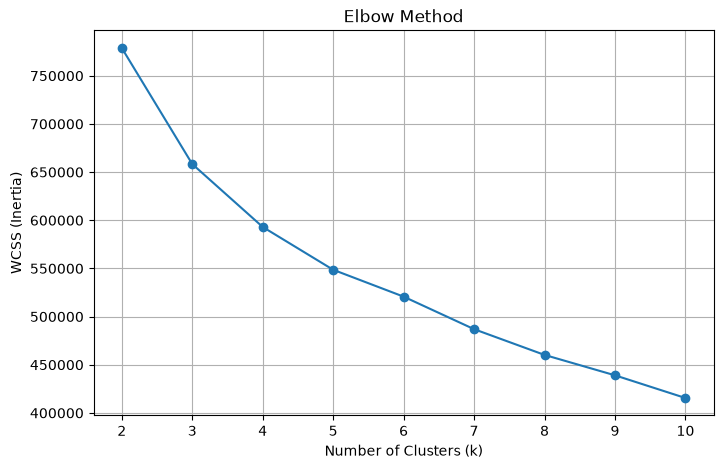

In [14]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

wcss = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(K, wcss, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")

plt.grid(True)

plt.show()



## silhouette_scores 

In [15]:


silhouette_scores = []

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled,
                            labels,
                            sample_size=5000,
                            random_state=42)

    silhouette_scores.append(score)

for k, score in zip(K, silhouette_scores):
    print(f"k = {k} --> Silhouette Score = {score:.4f}")

k = 2 --> Silhouette Score = 0.2045
k = 3 --> Silhouette Score = 0.2413
k = 4 --> Silhouette Score = 0.2312
k = 5 --> Silhouette Score = 0.1904
k = 6 --> Silhouette Score = 0.1600
k = 7 --> Silhouette Score = 0.1916
k = 8 --> Silhouette Score = 0.1699
k = 9 --> Silhouette Score = 0.1695
k = 10 --> Silhouette Score = 0.1778


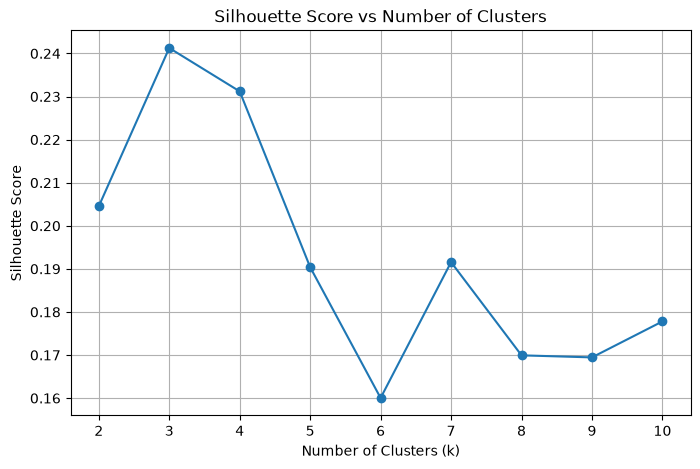

In [16]:
plt.figure(figsize=(8,5))

plt.plot(K, silhouette_scores, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")

plt.grid(True)

plt.show()

### Train the model and add cluster label to the dataset

In [17]:
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters
df.head()

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,Cluster
0,161427,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.325,0.654,133.088,1
1,223440,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.128,0.431,78.459,1
2,208267,0.511,0.206,-15.514,0.0592,0.995,0.000000,0.418,0.481,70.443,1
3,161933,0.676,0.467,-12.393,0.1650,0.991,0.000000,0.219,0.726,129.775,1
4,167973,0.650,0.298,-13.806,0.1380,0.991,0.000000,0.373,0.844,75.950,1


## check no of song in each cluster

Cluster
0    12513
1    30807
2    52517
Name: count, dtype: int64


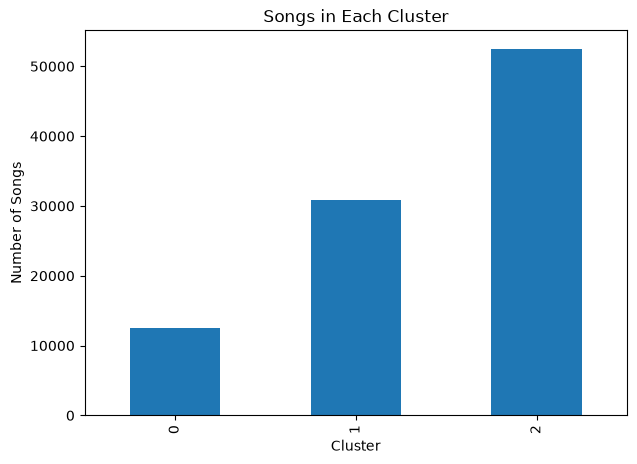

In [18]:
cluster_counts = df["Cluster"].value_counts().sort_index()

print(cluster_counts)

cluster_counts.plot(
    kind="bar",
    figsize=(7,5)
)

plt.xlabel("Cluster")
plt.ylabel("Number of Songs")
plt.title("Songs in Each Cluster")

plt.show()

## Cluster profiling

In [38]:
cluster_profile = df.groupby("Cluster")[features].mean()

print(cluster_profile.round(3))
cluster_profile.to_csv("cluster_summary.csv")

         danceability  energy  loudness  speechiness  acousticness  \
Cluster                                                              
0               0.664   0.467   -13.364        0.830         0.586   
1               0.486   0.311   -13.205        0.060         0.749   
2               0.627   0.694    -7.606        0.075         0.258   

         instrumentalness  liveness  valence    tempo  duration_ms  
Cluster                                                             
0                   0.001     0.436    0.584  100.389    97520.590  
1                   0.169     0.182    0.413  111.940   223457.064  
2                   0.051     0.200    0.666  124.911   226592.053  


## Export final dataset

In [39]:
df.to_csv(
    "Songs_Clustered.csv",
    index=False
)

## Visualize cluster profiling

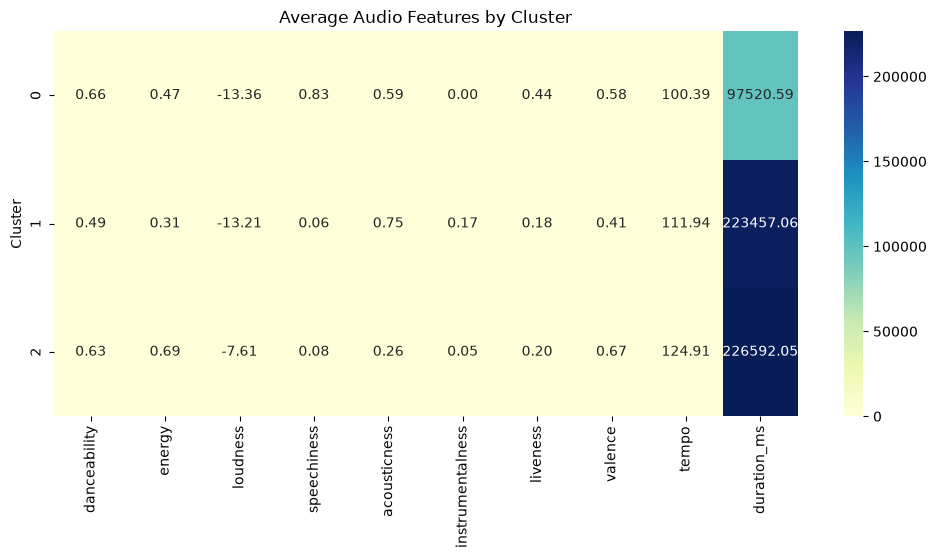

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Average Audio Features by Cluster")

plt.show()

## Cluster evaluation and interpretation

In [21]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(
    X_scaled,
    df["Cluster"],
    sample_size=5000,   # Use sampling for large datasets
    random_state=42
)

print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.2413


In [22]:
from sklearn.metrics import davies_bouldin_score

dbi = davies_bouldin_score(
    X_scaled,
    df["Cluster"]
)

print(f"Davies-Bouldin Index: {dbi:.4f}")

Davies-Bouldin Index: 1.5702


In [23]:
print(f"Inertia: {kmeans.inertia_:.2f}")

Inertia: 658335.08


## Visualization

### PCA visualization

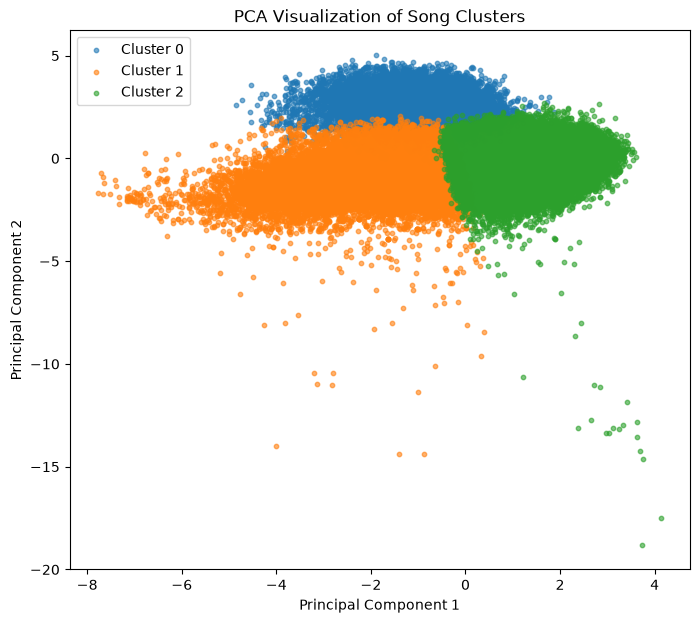

In [62]:
from sklearn.decomposition import PCA
import pandas as pd

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = df["Cluster"]

#----
#Scatter Plot


plt.figure(figsize=(8,7))

for cluster in sorted(pca_df["Cluster"].unique()):

    subset = pca_df[pca_df["Cluster"] == cluster]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=10,
        alpha=0.6,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Song Clusters")

plt.legend()

plt.show()

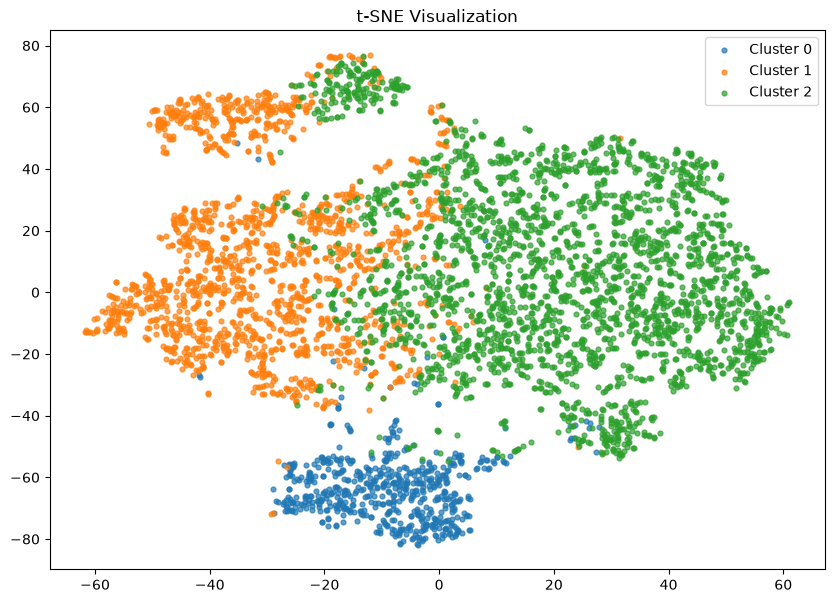

In [63]:
from sklearn.manifold import TSNE

sample = df.sample(5000, random_state=42)

X_sample = scaler.transform(sample[features])


tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_sample)

tsne_df = pd.DataFrame(
    X_tsne,
    columns=["TSNE1","TSNE2"]
)

tsne_df["Cluster"] = sample["Cluster"].values

plt.figure(figsize=(10,7))

for cluster in sorted(tsne_df["Cluster"].unique()):

    subset = tsne_df[tsne_df["Cluster"] == cluster]

    plt.scatter(
        subset["TSNE1"],
        subset["TSNE2"],
        s=12,
        alpha=0.7,
        label=f"Cluster {cluster}"
    )

plt.legend()

plt.title("t-SNE Visualization")

plt.show()

## Cluster profile bar chart

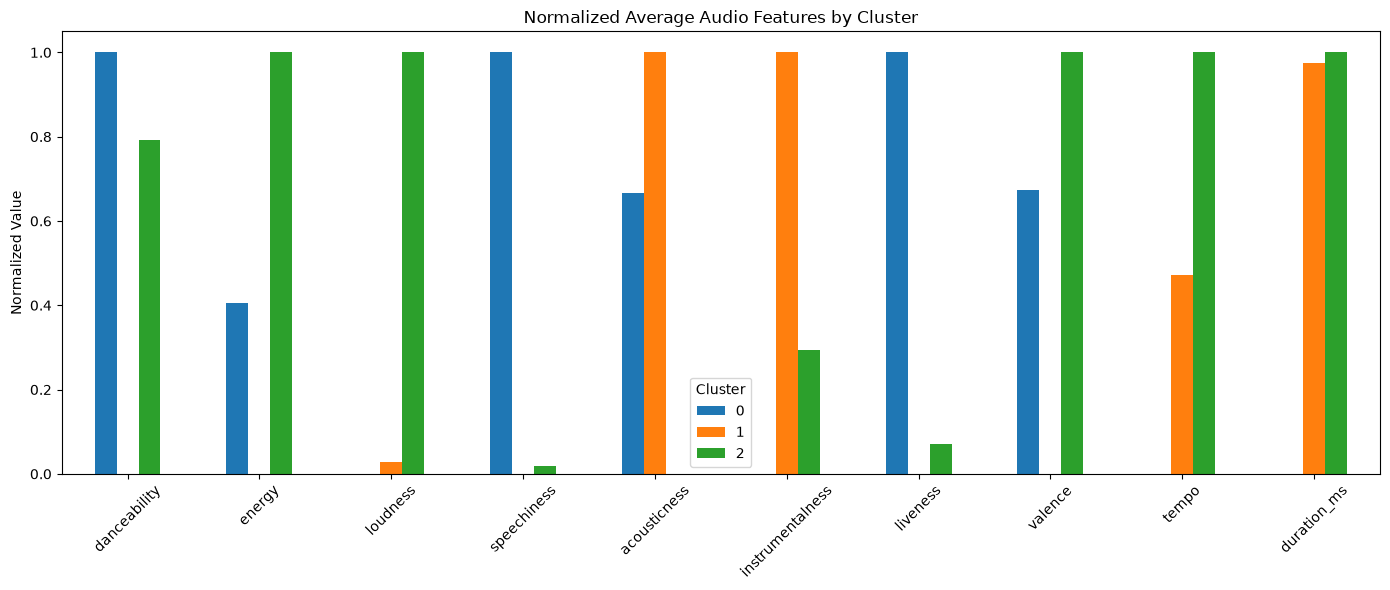

In [64]:
from sklearn.preprocessing import MinMaxScaler

cluster_profile = df.groupby("Cluster")[features].mean()

scaler = MinMaxScaler()

cluster_profile_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

cluster_profile_scaled.T.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Normalized Average Audio Features by Cluster")
plt.ylabel("Normalized Value")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.tight_layout()

plt.show()

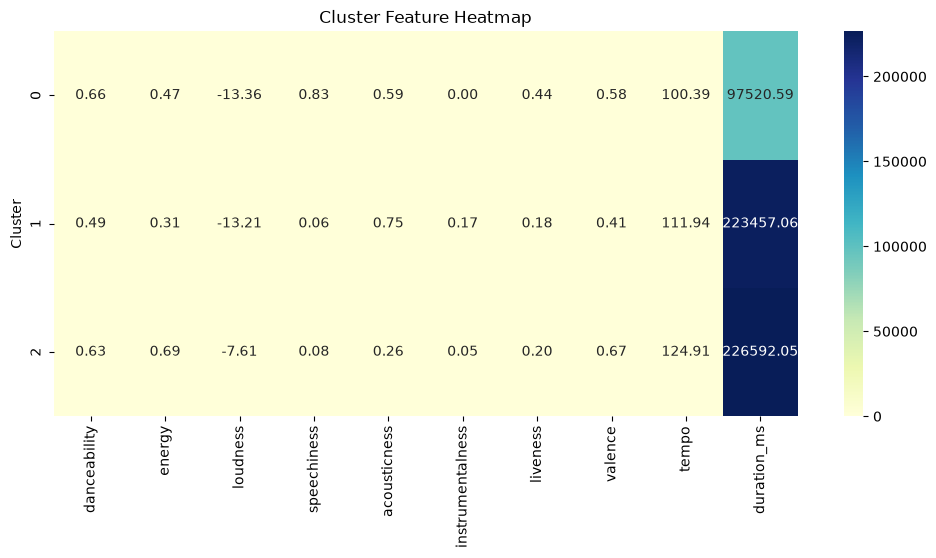

In [26]:
import seaborn as sns

plt.figure(figsize=(12,5))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Cluster Feature Heatmap")

plt.show()

## Distribution plots

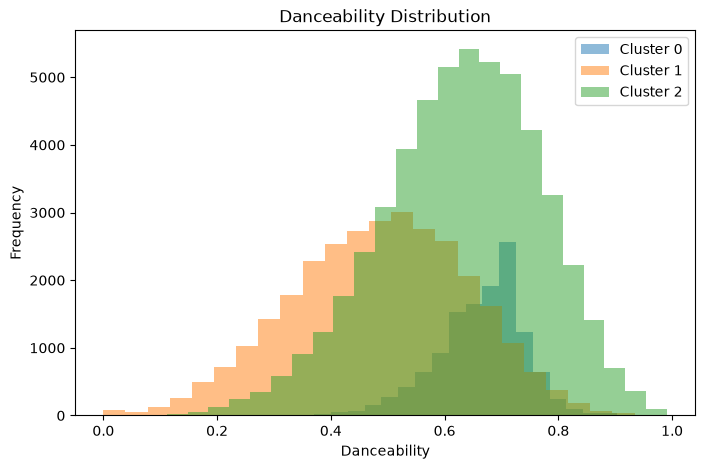

In [27]:
#danceability

plt.figure(figsize=(8,5))

for cluster in sorted(df["Cluster"].unique()):

    plt.hist(
        df[df["Cluster"]==cluster]["danceability"],
        bins=25,
        alpha=0.5,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Danceability")

plt.ylabel("Frequency")

plt.title("Danceability Distribution")

plt.legend()

plt.show()

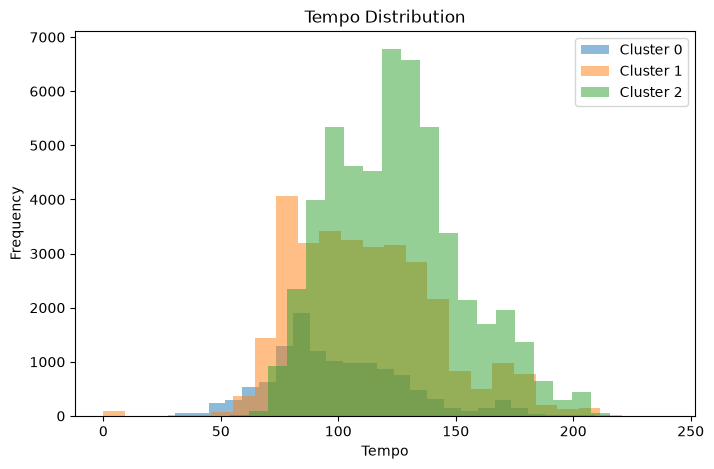

In [28]:
plt.figure(figsize=(8,5))

for cluster in sorted(df["Cluster"].unique()):

    plt.hist(
        df[df["Cluster"]==cluster]["tempo"],
        bins=25,
        alpha=0.5,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Tempo")

plt.ylabel("Frequency")

plt.title("Tempo Distribution")

plt.legend()

plt.show()

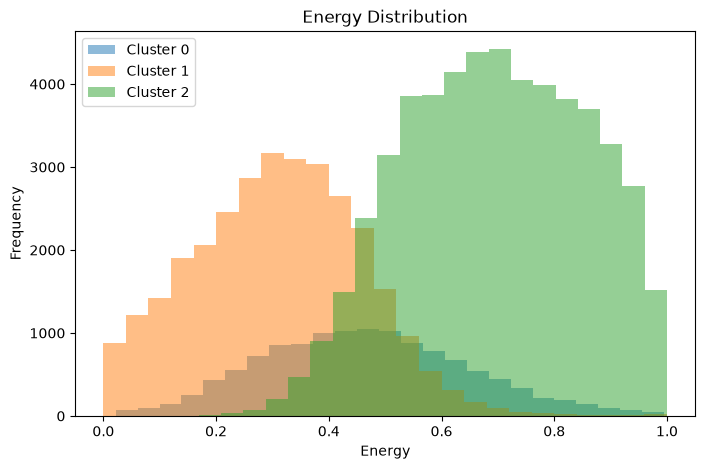

In [29]:
plt.figure(figsize=(8,5))

for cluster in sorted(df["Cluster"].unique()):

    plt.hist(
        df[df["Cluster"]==cluster]["energy"],
        bins=25,
        alpha=0.5,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Energy")

plt.ylabel("Frequency")

plt.title("Energy Distribution")

plt.legend()

plt.show()

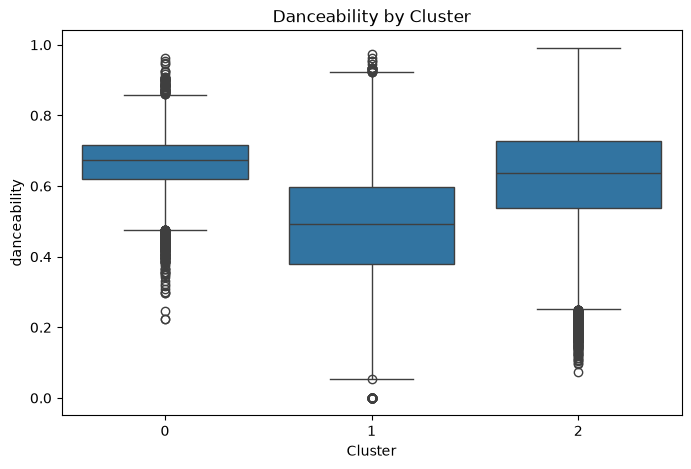

In [30]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Cluster",
    y="danceability",
    data=df
)

plt.title("Danceability by Cluster")

plt.show()

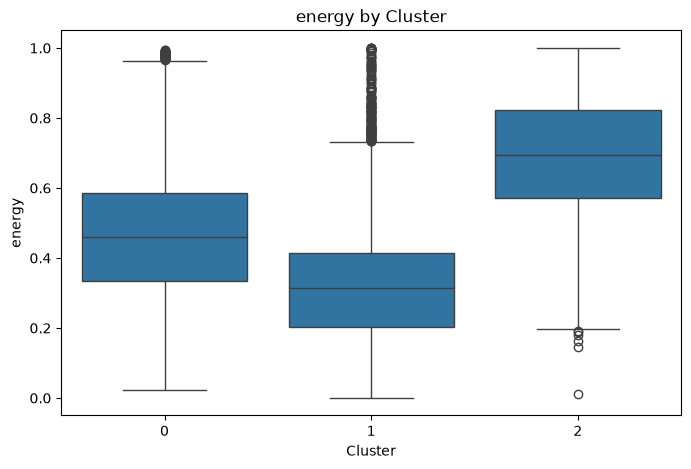

In [31]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Cluster",
    y="energy",
    data=df
)

plt.title("energy by Cluster")

plt.show()

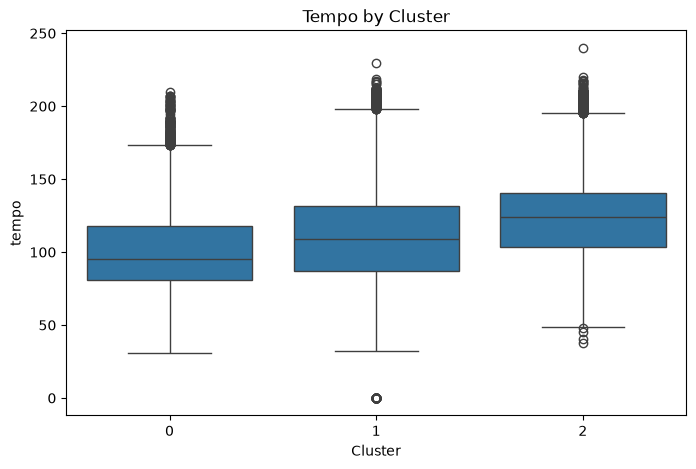

In [32]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Cluster",
    y="tempo",
    data=df
)

plt.title("Tempo by Cluster")

plt.show()

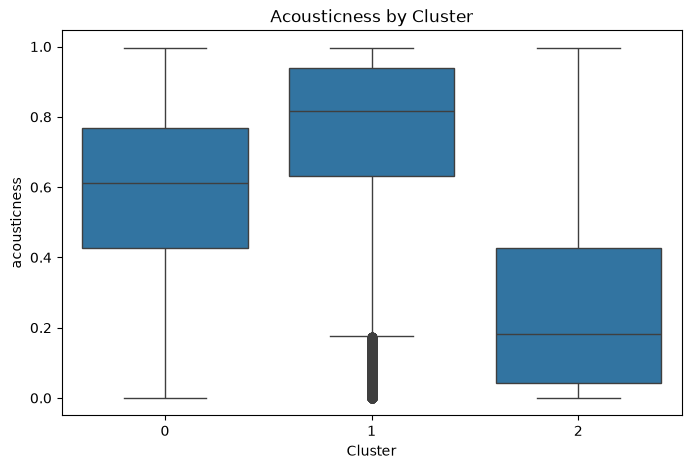

In [33]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Cluster",
    y="acousticness",
    data=df
)

plt.title("Acousticness by Cluster")

plt.show()

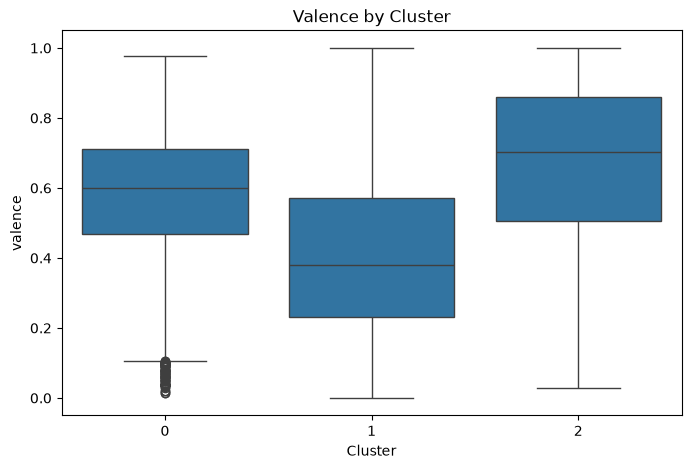

In [34]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Cluster",
    y="valence",
    data=df
)

plt.title("Valence by Cluster")

plt.show()

In [ ]:
## sort songs by cluster

clustered_df = df.sort_values(by="Cluster")

clustered_df.head(20)

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,Cluster
12601,230893,0.628,0.6330,-14.013,0.2500,0.511,0.0,0.854,0.803,159.962,0
12719,66115,0.613,0.3440,-17.664,0.9580,0.534,0.0,0.388,0.785,179.934,0
12718,66623,0.701,0.3140,-19.013,0.9600,0.602,0.0,0.185,0.680,76.841,0
12717,64503,0.692,0.0772,-21.262,0.9080,0.437,0.0,0.711,0.392,74.243,0
86004,176176,0.822,0.7200,-5.761,0.4580,0.250,0.0,0.614,0.821,93.381,0
12716,61464,0.715,0.2250,-20.074,0.9640,0.768,0.0,0.436,0.426,84.020,0
12715,66148,0.680,0.3030,-18.759,0.9610,0.607,0.0,0.291,0.696,92.527,0
12714,55630,0.593,0.2330,-21.356,0.9040,0.464,0.0,0.676,0.763,79.058,0
12713,60912,0.695,0.3820,-17.537,0.9410,0.844,0.0,0.661,0.849,87.868,0
12712,58409,0.680,0.1590,-19.525,0.9340,0.457,0.0,0.211,0.841,80.798,0


## DBSCAN

In [57]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

import numpy as np

dbscan = DBSCAN(
    eps=1.0,
    min_samples=10
)

db_labels = dbscan.fit_predict(X_scaled)


In [ ]:
## Add Cluster Labels
df["DBSCAN_Cluster"] = db_labels
df.head()

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,Cluster,DBSCAN_Cluster
0,161427,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.325,0.654,133.088,1,0
1,223440,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.128,0.431,78.459,1,0
2,208267,0.511,0.206,-15.514,0.0592,0.995,0.000000,0.418,0.481,70.443,1,0
3,161933,0.676,0.467,-12.393,0.1650,0.991,0.000000,0.219,0.726,129.775,1,0
4,167973,0.650,0.298,-13.806,0.1380,0.991,0.000000,0.373,0.844,75.950,1,0


## Check no of clusters

In [53]:
unique_clusters = np.unique(db_labels)

print(unique_clusters)

[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [59]:
print(df["DBSCAN_Cluster"].value_counts())

DBSCAN_Cluster
 0     82519
-1     13081
 10       33
 6        27
 8        19
 15       16
 2        13
 4        12
 11       12
 5        11
 9        10
 17       10
 12       10
 13        9
 7         9
 18        9
 1         8
 3         8
 14        8
 19        7
 16        6
Name: count, dtype: int64


In [61]:
noise = list(db_labels).count(-1)

print("Noise Points:", noise)

Noise Points: 13081


In [60]:
noise = (df["DBSCAN_Cluster"] == -1).sum()
print(noise)

13081
